In [1]:
from mymodels import AlexNet, train, test_error, kCV
from dataUtils import *
from sklearn.model_selection import KFold
from sklearn.metrics import mean_squared_error, r2_score
from torch.utils.data import Subset
from torcheval.metrics import R2Score
from torch import nn,optim,save,load,Tensor,cat,no_grad
import matplotlib.pyplot as plt
import time
from torch.cuda import synchronize
device = 'cuda'
netName = 'alex'

In [ ]:
best = load_json(f'HPO/{netName}net_SGD_cv.json')
print(best)
model_params = {'dropout':best['dropout']}
model = AlexNet
net = model(**model_params) 
loss_fn = nn.MSELoss
optimizer = optim.SGD
increase_perc = 0
opt_params = {'lr': best['lr'], 'weight_decay':1e-4, 'momentum': best['momentum']}
epochs = 50
batch_size = best['batch_size']
epochs_loss = train(
    net,
    loss_fn(),
    optimizer(net.parameters(),**opt_params),
    epochs,
    make_train_loader(batch_size=batch_size,increase_perc=increase_perc),
    make_validation_loader(batch_size=batch_size),
    device='cuda'
)

{'dropout': 0.2, 'lr': 0.0001256495873508423, 'batch_size': 32, 'momentum': 0.9, 'loss': 0.021364712343690383}
EPOCH 1
	train loss:	 0.05138564499851206
	val. loss:	 0.04719048137353225
EPOCH 2
	train loss:	 0.047107282896885774
	val. loss:	 0.04211893237449906
EPOCH 3
	train loss:	 0.044293236586790866
	val. loss:	 0.040783974596045235
EPOCH 4
	train loss:	 0.04238961628721197
	val. loss:	 0.03994524461979216
EPOCH 5
	train loss:	 0.04099655013051954
	val. loss:	 0.039525870233774185
EPOCH 6
	train loss:	 0.039719183634192044
	val. loss:	 0.03754336014389992
EPOCH 7
	train loss:	 0.03808408211179004
	val. loss:	 0.03702168759297241
EPOCH 8
	train loss:	 0.03629772968147651
	val. loss:	 0.03516930536451665
EPOCH 9
	train loss:	 0.036276084343248076
	val. loss:	 0.03530028792606159
EPOCH 10
	train loss:	 0.03561308430415569
	val. loss:	 0.03437478510154919
EPOCH 11
	train loss:	 0.0339581647906268
	val. loss:	 0.03191529341380705
EPOCH 12
	train loss:	 0.033159274312824304
	val. loss:	 

In [3]:
dataset = make_train_val_set()
cv_loss = kCV(5,dataset,model,model_params,loss_fn,optimizer,opt_params=opt_params,epochs=epochs,batch_size=batch_size)
save(net.state_dict(), f'models/{netName}_net.pth')

FOLD 0
EPOCH 1
	train loss:	 0.05483343765823817
	val. loss:	 0.04339158410206437
EPOCH 2
	train loss:	 0.048877506193761924
	val. loss:	 0.03992406852543354
EPOCH 3
	train loss:	 0.04568456685436623
	val. loss:	 0.037527547040954234
EPOCH 4
	train loss:	 0.04255304532125592
	val. loss:	 0.03612852508202195
EPOCH 5
	train loss:	 0.04101292135155931
	val. loss:	 0.035036178147420285
EPOCH 6
	train loss:	 0.039672999101101745
	val. loss:	 0.03259742736816406
EPOCH 7
	train loss:	 0.037588676656311264
	val. loss:	 0.03148681502789259
EPOCH 8
	train loss:	 0.03647976744996042
	val. loss:	 0.030107595501467587
EPOCH 9
	train loss:	 0.03558917189663162
	val. loss:	 0.028674681428819893
EPOCH 10
	train loss:	 0.03412472450041345
	val. loss:	 0.02766746325418353
EPOCH 11
	train loss:	 0.03307133642196351
	val. loss:	 0.027001907490193842
EPOCH 12
	train loss:	 0.03131975126167645
	val. loss:	 0.02581787671893835
EPOCH 13
	train loss:	 0.030917540506212687
	val. loss:	 0.024751537423580886
EPOC

In [ ]:
to_json(f'results/{netName}net.json',{**epochs_loss,**{'cv':cv_loss,'test':test_error(net,make_test_set())}})

In [2]:
net = AlexNet()
net.load_state_dict(load(f'models/{netName}_net.pth',weights_only=True))

/home/aislab/.local/lib/python3.8/site-packages/torch/_utils.py:776: UserWarning: TypedStorage is deprecated. It will be removed in the future and UntypedStorage will be the only storage class. This should only matter to you if you are using storages directly.  To access UntypedStorage directly, use tensor.untyped_storage() instead of tensor.storage()
  return self.fget.__get__(instance, owner)()


<All keys matched successfully>

In [4]:
epochs_loss = load_json(f'results/{netName}net.json')
cv = epochs_loss['cv']
test = epochs_loss['test']
validation = epochs_loss['validation'][-1]
train = epochs_loss['train'][-1]
print(f'train: {train}\nvalid.: {validation}\ntest: {test}\ncv: {cv}')

train: 0.018037263299384626
valid.: 0.01807767370800403
test: 0.01691927863238112
cv: 0.017176229482516646


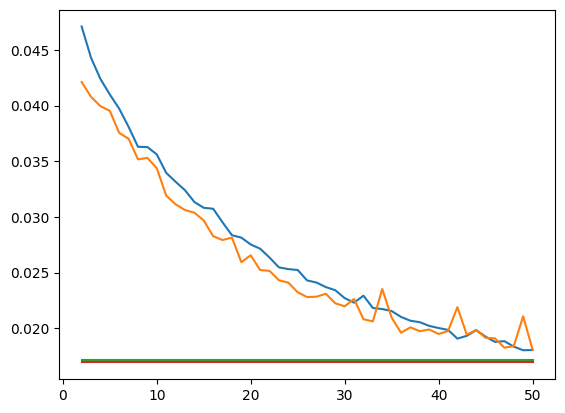

In [5]:
epochs = len(epochs_loss['validation'])
first_epoch = 2
epochsX = range(first_epoch,epochs+1)
plt.plot(epochsX, epochs_loss['train'][first_epoch-1:])
plt.plot(epochsX, epochs_loss['validation'][first_epoch-1:])
plt.plot([first_epoch,epochs], [cv]*2)
plt.plot([first_epoch,epochs], [test]*2)

In [132]:
testloader = DataLoader(
    make_test_set(), batch_size=4, shuffle=False, num_workers=1
)
net.eval()
total_time = 0
device = 'cuda'
net.to(device)
test_error(net,make_test_set(),device='cuda') #WARM UP
for data in testloader:
    x, area, ate, are = data
    x = x.to(device)
    area = area.to(device)
    ate = ate.to(device)
    are = are.to(device)
    synchronize()
    start_time = time.time()
    outputs = net(x,area)
    synchronize()
    end_time = time.time()
    total_time += (end_time-start_time)/len(data)
inf_time = total_time/len(testloader)
print(f'inference time GPU: {inf_time}')
total_time = 0
device = 'cpu'
net.to(device)
test_error(net,make_test_set(),device='cpu') #WARM UP
for data in testloader:
    x, area, ate, are = data
    x = x.to(device)
    area = area.to(device)
    ate = ate.to(device)
    are = are.to(device)
    synchronize()
    start_time = time.time()
    outputs = net(x,area)
    synchronize()
    end_time = time.time()
    total_time += (end_time-start_time)/len(data)
inf_time = total_time/len(testloader)
print(f'inference time CPU: {inf_time}')

inference time GPU: 0.0002523369487674757
inference time CPU: 0.01681659858802269


In [9]:
param_size = 0
for param in net.parameters():
    param_size += param.nelement() * param.element_size()
buffer_size = 0
for buffer in net.buffers():
    buffer_size += buffer.nelement() * buffer.element_size()

size_all_mb = (param_size + buffer_size) / 1024**2
print('model size: {:.3f}MB'.format(size_all_mb))

model size: 142.300MB


In [3]:
test_load = make_test_loader()
n = len(test_load)
predicted = []
areas = []
real = []
net.cpu()
net.eval()
with no_grad():
    for map,area,ate,are in test_load:
        yhat = net(map,area).squeeze(0).numpy()
        predicted += [yhat]
        real += [cat([ate,are]).numpy()]

torch.Size([1, 4096])
torch.Size([1, 4096])
torch.Size([1, 4096])
torch.Size([1, 4096])
torch.Size([1, 4096])
torch.Size([1, 4096])
torch.Size([1, 4096])
torch.Size([1, 4096])
torch.Size([1, 4096])
torch.Size([1, 4096])
torch.Size([1, 4096])
torch.Size([1, 4096])
torch.Size([1, 4096])
torch.Size([1, 4096])
torch.Size([1, 4096])
torch.Size([1, 4096])
torch.Size([1, 4096])
torch.Size([1, 4096])
torch.Size([1, 4096])
torch.Size([1, 4096])
torch.Size([1, 4096])
torch.Size([1, 4096])
torch.Size([1, 4096])
torch.Size([1, 4096])
torch.Size([1, 4096])
torch.Size([1, 4096])
torch.Size([1, 4096])
torch.Size([1, 4096])
torch.Size([1, 4096])
torch.Size([1, 4096])
torch.Size([1, 4096])
torch.Size([1, 4096])
torch.Size([1, 4096])
torch.Size([1, 4096])
torch.Size([1, 4096])
torch.Size([1, 4096])
torch.Size([1, 4096])
torch.Size([1, 4096])
torch.Size([1, 4096])
torch.Size([1, 4096])
torch.Size([1, 4096])
torch.Size([1, 4096])
torch.Size([1, 4096])
torch.Size([1, 4096])
torch.Size([1, 4096])
torch.Size

In [122]:
Predicted = np.array([np.array(revert_data_norm(ate,are)) for ate,are in predicted])
Real = np.array([np.array(revert_data_norm(ate,are)) for ate,are in real])
pAte = Predicted[:,0]
pAre = Predicted[:,1]
rAte = Real[:,0]
rAre = Real[:,1]
R2_ate = r2_score(rAte,pAte)
R2_are = r2_score(rAre,pAre)
RMSE_ate = np.sqrt(mean_squared_error(rAte,pAte))
RMSE_are = np.sqrt(mean_squared_error(rAre,pAre))
NRMSE_ate = RMSE_ate/(pAte.max()-pAte.min())
NRMSE_are = RMSE_are/(pAre.max()-pAre.min())
print(f'ATE\n\tR2: {round(R2_ate,3)}\tRMSE: {round(RMSE_ate,3)}\tNRMSE: {round(NRMSE_ate,3)}\t')
print(f'ARE\n\tR2: {round(R2_are,3)}\tRMSE: {round(RMSE_are,3)}\tNRMSE: {round(NRMSE_are,3)}\t')

ATE
	R2: 0.404	RMSE: 1.193	NRMSE: 0.278	
ARE
	R2: 0.815	RMSE: 0.017	NRMSE: 0.086	
